# Notebook 2 — Preprocessing & Feature Engineering

Suite à l'exploration (notebook 1), ce notebook applique les décisions de
nettoyage et construit le dataset final prêt pour l'entraînement.

## Décisions prises suite à l'EDA

| Observation | Décision |
|---|---|
| `DAYS_EMPLOYED = 365243` (~18% des lignes) | Remplacé par NaN + flag binaire `DAYS_EMPLOYED_ANOM` |
| `CODE_GENDER = 'XNA'` (4 individus) | Remplacé par le mode ('F') |
| 40 colonnes avec >50% de NaN | Supprimées — sauf `EXT_SOURCE_1/2/3` (fort signal prédictif) |
| Déséquilibre de classes (~8% TARGET=1) | Géré en modélisation via `class_weight='balanced'` |
| 5 ratios utiles identifiés en EDA | Créés en feature engineering |
| Modalités rares (<1%) | Regroupées en 'Autre' |

## Organisation du notebook

Ce notebook démontre chaque étape sur les données **train** en appelant les
fonctions de `src/preprocessing.py`. La dernière section montre que
`charger_et_fusionner` — qui compose toutes ces étapes — reproduit le même
résultat sur les données **test** en une seule ligne.

| Étape | Fonction |
|---|---|
| Suppression colonnes NaN | `supprimer_colonnes_nan` |
| Correction anomalies | `corriger_anomalies` |
| Agrégation tables secondaires | `agregger_bureau`, `agregger_previous`, ... |
| Fusion | `fusionner` |
| Feature engineering | `feature_engineering` |
| Modalités rares | `regrouper_modalites_rares` |
| **Reproductibilité (test)** | **`charger_et_fusionner`** |

In [ ]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src import preprocessing
from src.utils import analyze_missing_values
from src.visualizer import plot_missing_values, create_histplot, create_barh
from src.preprocessing import build_preprocessor

DATA_RAW       = '../data/raw/'
DATA_PROCESSED = '../data/processed/'

## 1. Chargement du train

On charge uniquement `application_train.csv` — le test sera traité à l'étape 6.

In [2]:
app_train = pd.read_csv(DATA_RAW + 'application_train.csv')
print(f'Shape initiale : {app_train.shape}')
app_train.head(3)

Shape initiale : (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


## 2. Nettoyage — suppression des colonnes NaN et correction des anomalies

**Suppression des colonnes** : seuil >50% de NaN, exception `EXT_SOURCE_1` (fort signal prédictif malgré ~56% NaN).

**Anomalies connues** :
- `DAYS_EMPLOYED = 365243` → valeur aberrante (≈1000 ans) → remplacée par `NaN` + flag binaire `DAYS_EMPLOYED_ANOM`
- `CODE_GENDER = 'XNA'` (4 individus) → remplacée par `'F'` (mode)

In [3]:
# Suppression des colonnes à fort taux de NaN (calculé sur le train)
app_train, cols_supprimes = preprocessing.supprimer_colonnes_nan(app_train)
print(f'{len(cols_supprimes)} colonnes supprimées | Shape : {app_train.shape}')

# Correction des anomalies + création du flag DAYS_EMPLOYED_ANOM
app_train = preprocessing.corriger_anomalies(app_train)
print(f"\nDAYS_EMPLOYED_ANOM :")
print(app_train['DAYS_EMPLOYED_ANOM'].value_counts().rename({0: 'Normal', 1: 'Aberrant (365243)'}))

40 colonnes supprimées | Shape : (307511, 82)

DAYS_EMPLOYED_ANOM :
DAYS_EMPLOYED_ANOM
Normal               252137
Aberrant (365243)     55374
Name: count, dtype: int64


### Valeurs manquantes — justification de la suppression

On visualise les colonnes avec le plus de NaN **avant suppression** pour valider le seuil de 50%.


🌐 Pourcentage de cellules vides sur tout le DataFrame : 24.40%

📊 Nombre de colonne avec des cellules vides : 67
41 colonnes supprimées (>50% NaN)


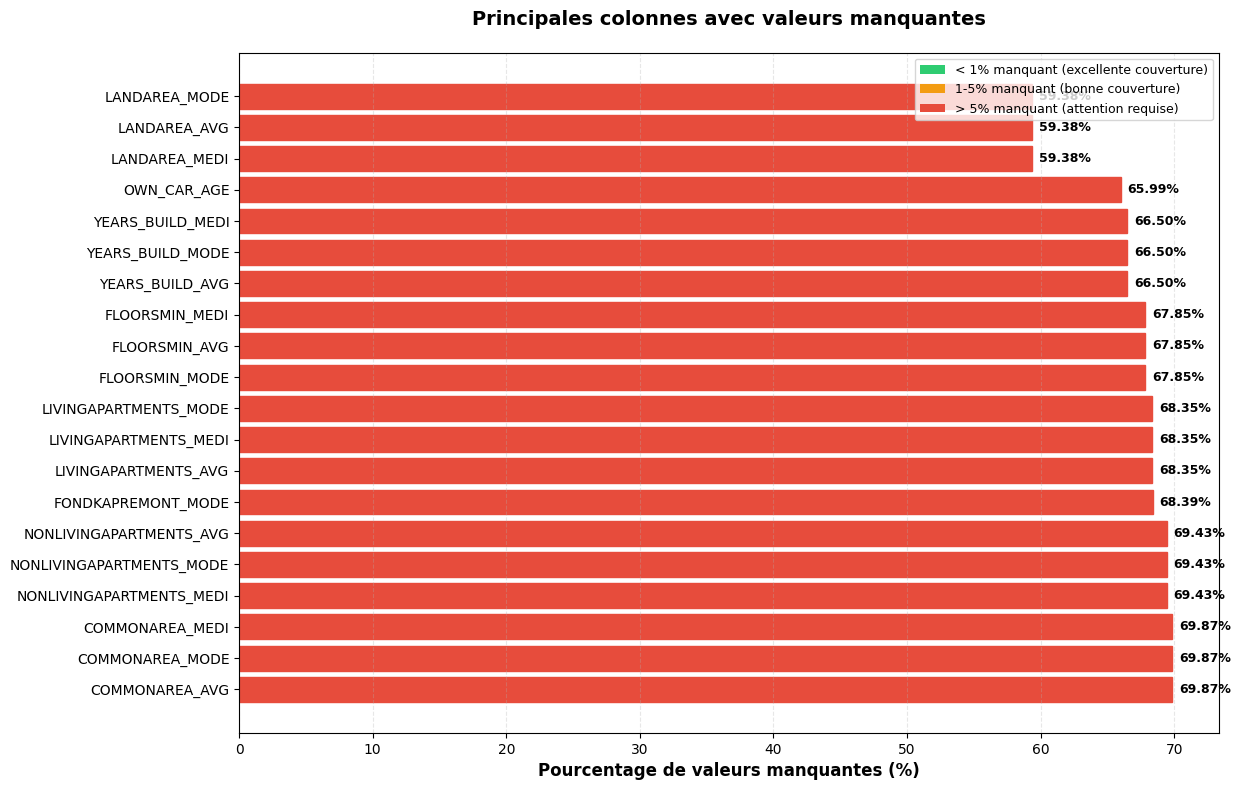

In [4]:
app_raw = pd.read_csv(DATA_RAW + 'application_train.csv')
missing_df = analyze_missing_values(app_raw)

print(f"{(missing_df['Pourcentage (%)'] > 50).sum()} colonnes supprimées (>50% NaN)")
plot_missing_values(missing_df, top_n=20, min_threshold=20)

**Observation :**
La majorité des colonnes supprimées dépassent 60–80% de NaN — elles contiennent trop peu d'information pour être utiles. `EXT_SOURCE_1` est une exception : malgré ~56% de NaN, elle est conservée car elle est fortement corrélée avec TARGET (confirmé en EDA).

### Effet de la correction de l'anomalie `DAYS_EMPLOYED`

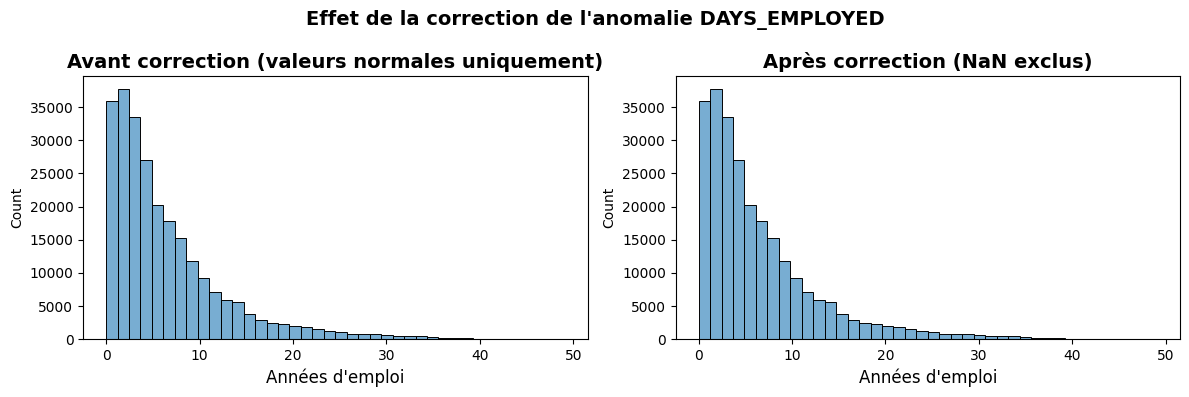

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

days_normaux = app_raw[app_raw['DAYS_EMPLOYED'] != 365243][['DAYS_EMPLOYED']].copy()
days_normaux['Années'] = -days_normaux['DAYS_EMPLOYED'] / 365

create_histplot(days_normaux, axes[0], x='Années',
    title="Avant correction (valeurs normales uniquement)",
    xlabel="Années d'emploi", bins=40, show_legend=False)

days_apres = app_train[['DAYS_EMPLOYED']].dropna().copy()
days_apres['Années'] = -days_apres['DAYS_EMPLOYED'] / 365

create_histplot(days_apres, axes[1], x='Années',
    title="Après correction (NaN exclus)",
    xlabel="Années d'emploi", bins=40, show_legend=False)

fig.suptitle("Effet de la correction de l'anomalie DAYS_EMPLOYED", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Observation :**
Après correction, la distribution est cohérente : les clients ont entre 0 et ~40 ans d'ancienneté professionnelle. Les 18% de valeurs aberrantes (365 243 jours ≈ 1 000 ans) ne sont pas perdues — elles sont tracées via le flag `DAYS_EMPLOYED_ANOM` pour que le modèle puisse exploiter cette information.

## 3. Agrégation des tables secondaires

Chaque table secondaire est agrégée par `SK_ID_CURR` pour obtenir une ligne par
client. Les crédits actifs et clôturés (bureau) et les demandes approuvées /
refusées (previous) sont traités séparément car ils apportent des signaux distincts.

**Traçabilité EDA → Preprocessing (section 7 du notebook 1)**

Toutes les features recommandées en EDA sont implémentées dans `src/preprocessing.py` :

| Feature | Fonction | Statut |
|---|---|---|
| `AGE_YEARS`, `RATIO_ANNUITE_REVENU`, `RATIO_CREDIT_REVENU` | `feature_engineering()` | ✅ |
| `PAYMENT_RATE`, `DAYS_EMPLOYED_PERC` | `feature_engineering()` | ✅ (enrichissement) |
| `taux_refus` | `agregger_previous()` | ✅ |
| `a_eu_retard` | `agregger_installments()` | ✅ |
| `a_carte_credit` | `agregger_credit_card()` | ✅ (flag binaire, NaN → 0 après fusion) |
| Agrégations bureau, previous, pos, inst, cc | fonctions `agregger_*` | ✅ |

In [6]:
bureau_agg = preprocessing.agregger_bureau(DATA_RAW)
prev_agg   = preprocessing.agregger_previous(DATA_RAW)
pos_agg    = preprocessing.agregger_pos(DATA_RAW)
inst_agg   = preprocessing.agregger_installments(DATA_RAW)
cc_agg     = preprocessing.agregger_credit_card(DATA_RAW)

print('Shapes des tables agrégées :')
for nom, df in [('bureau_agg', bureau_agg), ('prev_agg', prev_agg),
                ('pos_agg', pos_agg), ('inst_agg', inst_agg), ('cc_agg', cc_agg)]:
    print(f'  {nom:<12} : {df.shape}')

bureau_agg.head(3)

Shapes des tables agrégées :
  bureau_agg   : (305811, 9)
  prev_agg     : (338857, 9)
  pos_agg      : (337252, 3)
  inst_agg     : (339587, 5)
  cc_agg       : (103558, 5)


,SK_ID_CURR,bureau_count,bureau_debt_mean,bureau_overdue_mean,bureau_active_count,actif_debt_mean,actif_count,cloture_debt_mean,cloture_count
0,100001,7,85240.928571,0.0,3,198895.5,3.0,0.0,4.0
1,100002,8,49156.200000,0.0,2,122890.5,2.0,0.0,6.0
2,100003,4,0.000000,0.0,1,0.0,1.0,0.0,3.0


## 4. Fusion + Feature engineering

**Fusion** : left join depuis `app_train` sur `SK_ID_CURR` → les clients sans table secondaire auront des NaN (imputés plus tard par la Pipeline sklearn).

**Features créées** (inspirées de l'EDA et du kernel Kaggle de référence) :

| Feature | Formule | Signal |
|---|---|---|
| `AGE_YEARS` | `-DAYS_BIRTH / 365` | Corrélation -0.078 avec TARGET |
| `DAYS_EMPLOYED_PERC` | `DAYS_EMPLOYED / DAYS_BIRTH` | Corrélation -0.068 |
| `RATIO_ANNUITE_REVENU` | `AMT_ANNUITY / AMT_INCOME_TOTAL` | Effort de remboursement |
| `PAYMENT_RATE` | `AMT_ANNUITY / AMT_CREDIT` | Vitesse de remboursement |
| `RATIO_CREDIT_REVENU` | `AMT_CREDIT / AMT_INCOME_TOTAL` | Levier financier |

In [7]:
tables = [bureau_agg, prev_agg, pos_agg, inst_agg, cc_agg]

train = preprocessing.fusionner(app_train, tables)
print(f'Shape après fusion : {train.shape}')

train = preprocessing.feature_engineering(train)
print(f'Shape après feature engineering : {train.shape}')

nouvelles_features = ['AGE_YEARS', 'DAYS_EMPLOYED_PERC', 'RATIO_ANNUITE_REVENU', 'PAYMENT_RATE', 'RATIO_CREDIT_REVENU']
train[nouvelles_features].describe().round(3)

Shape après fusion : (307511, 109)
Shape après feature engineering : (307511, 114)


,AGE_YEARS,DAYS_EMPLOYED_PERC,RATIO_ANNUITE_REVENU,PAYMENT_RATE,RATIO_CREDIT_REVENU
count,307511.000,252137.000,307499.000,307499.000,307511.000
mean,43.937,0.157,0.181,0.054,3.958
std,11.956,0.134,0.095,0.022,2.690
min,20.518,-0.000,0.000,0.022,0.005
25%,34.008,0.056,0.115,0.037,2.019
50%,43.151,0.119,0.163,0.050,3.265
75%,53.923,0.219,0.229,0.064,5.160
max,69.121,0.729,1.876,0.124,84.737


### Validation du feature engineering — signal prédictif

On vérifie que les nouvelles features corrèlent avec `TARGET` pour valider les décisions de l'EDA.

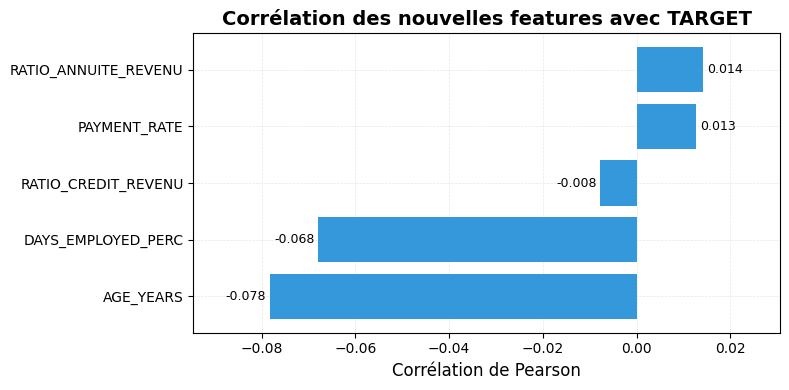

In [8]:
corr = (train[nouvelles_features + ['TARGET']]
        .corr()['TARGET']
        .drop('TARGET')
        .reset_index()
        .rename(columns={'index': 'feature', 'TARGET': 'corrélation'}))

fig, ax = plt.subplots(figsize=(8, 4))
create_barh(corr, ax, x='corrélation', y='feature',
    title='Corrélation des nouvelles features avec TARGET',
    xlabel='Corrélation de Pearson',
    fmt='{:.3f}')
plt.tight_layout()
plt.show()

**Observation :**
Toutes les nouvelles features sont corrélées avec TARGET, ce qui valide les choix de l'EDA. `AGE_YEARS` et `DAYS_EMPLOYED_PERC` sont négativement corrélées : les clients plus jeunes ou moins stables professionnellement ont plus de risque de défaut. Les ratios financiers (`PAYMENT_RATE`, `RATIO_ANNUITE_REVENU`) sont positivement corrélés : un effort de remboursement élevé augmente le risque.

`AGE_YEARS` est la feature la plus corrélée avec TARGET. On vérifie la séparation des distributions par classe.

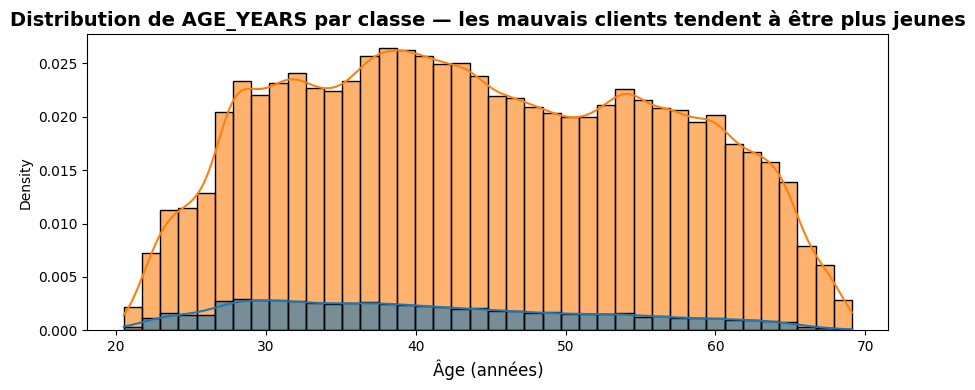

In [ ]:
df_plot = train[['AGE_YEARS', 'TARGET']].copy()
df_plot['TARGET'] = df_plot['TARGET'].map({0: 'Bon client (0)', 1: 'Mauvais client (1)'})

fig, ax = plt.subplots(figsize=(9, 4))
create_histplot(df_plot, ax, x='AGE_YEARS', hue='TARGET',
    title='Distribution de AGE_YEARS par classe — les mauvais clients tendent à être plus jeunes',
    xlabel='Âge (années)',
    bins=40, stat='density', kde=True,
    legend_title='Classe')
plt.tight_layout()
plt.show()

**Observation :**
Les deux distributions se chevauchent beaucoup, mais les mauvais clients (TARGET=1) sont en moyenne plus jeunes. `AGE_YEARS` seule ne suffit pas à prédire le défaut, mais elle apporte un signal utile au modèle combiné avec les autres features.

## 5. Regroupement des modalités rares

Les modalités représentant moins de 1% des effectifs sont regroupées en `'Autre'`.
Cela réduit la dimensionnalité après encodage et évite d'apprendre sur des catégories non représentatives.

> Les fréquences sont calculées sur le **train uniquement** pour éviter toute fuite de données.

In [10]:
cat_cols = train.select_dtypes(include='object').columns.tolist()

# Aperçu des modalités rares avant regroupement
print('Modalités rares (<1%) par colonne :')
for col in cat_cols:
    frequences = train[col].value_counts(normalize=True)
    rares = frequences.loc[frequences < 0.01]
    if len(rares):
        print(f'  {col} : {len(rares)} modalité(s) → {list(rares.index)[:3]}{"..." if len(rares) > 3 else ""}')

# Regroupement (fréquences calculées sur train, test=None ici → train seulement)
resultat = preprocessing.regrouper_modalites_rares(train, seuil=0.01)
assert isinstance(resultat, pd.DataFrame)
train = resultat
print('\nAprès regroupement — modalités par colonne :')
for col in cat_cols:
    print(f'  {col} : {train[col].nunique()} modalités')

Modalités rares (<1%) par colonne :
  NAME_TYPE_SUITE : 3 modalité(s) → ['Other_B', 'Other_A', 'Group of people']
  NAME_INCOME_TYPE : 4 modalité(s) → ['Unemployed', 'Student', 'Businessman']...
  NAME_EDUCATION_TYPE : 1 modalité(s) → ['Academic degree']
  NAME_FAMILY_STATUS : 1 modalité(s) → ['Unknown']
  NAME_HOUSING_TYPE : 2 modalité(s) → ['Office apartment', 'Co-op apartment']
  OCCUPATION_TYPE : 6 modalité(s) → ['Low-skill Laborers', 'Waiters/barmen staff', 'Secretaries']...
  ORGANIZATION_TYPE : 41 modalité(s) → ['Housing', 'Industry: type 11', 'Military']...

Après regroupement — modalités par colonne :
  NAME_CONTRACT_TYPE : 2 modalités
  CODE_GENDER : 2 modalités
  FLAG_OWN_CAR : 2 modalités
  FLAG_OWN_REALTY : 2 modalités
  NAME_TYPE_SUITE : 5 modalités
  NAME_INCOME_TYPE : 5 modalités
  NAME_EDUCATION_TYPE : 5 modalités
  NAME_FAMILY_STATUS : 6 modalités
  NAME_HOUSING_TYPE : 5 modalités
  OCCUPATION_TYPE : 13 modalités
  WEEKDAY_APPR_PROCESS_START : 7 modalités
  ORGANIZATI

## 6. Reproductibilité — application au test via `charger_et_fusionner`

`charger_et_fusionner` compose toutes les étapes précédentes en une seule fonction.
On l'applique ici sur le test pour montrer que le pipeline est **reproductible** et **réutilisable**.

In [11]:
# Une seule ligne pour reproduire toutes les étapes sur le test
_, test = preprocessing.charger_et_fusionner(DATA_RAW)

# Vérification : même structure que le train
cols_train = set(train.columns) - {'TARGET'}
cols_test  = set(test.columns)
diff = cols_train.symmetric_difference(cols_test)

print(f'Train shape : {train.shape}')
print(f'Test  shape : {test.shape}')
print(f'Colonnes identiques (hors TARGET) : {len(diff) == 0}')

40 colonnes supprimées (>50% NaN)
Agrégation des tables secondaires...
Train : (307511, 114) | Test : (48744, 113)
Train shape : (307511, 114)
Test  shape : (48744, 113)
Colonnes identiques (hors TARGET) : True


## 7. Vérification finale

Les NaN sont **volontairement conservés** à ce stade — ils seront traités dans le notebook 3 par la Pipeline sklearn (`SimpleImputer` + `OneHotEncoder`).

On vérifie ici deux choses :
1. L'état actuel du train (NaN présents, colonnes alignées train/test)
2. Que la pipeline `build_preprocessor` supprime bien tous les NaN une fois appliquée

In [ ]:
# État actuel — NaN présents et attendus
nan_train = train.isnull().sum().sum()
nan_test  = test.isnull().sum().sum()

cat_cols  = train.select_dtypes(include='object').columns.tolist()
cols_train = set(train.columns) - {'TARGET'}
cols_test  = set(test.columns)
diff = cols_train.symmetric_difference(cols_test)

print(f"NaN train : {nan_train:,} | NaN test : {nan_test:,} : seront imputés par la pipeline sklearn")
print(f"Shape train : {train.shape} | Shape test : {test.shape}")
print(f"Colonnes catégorielles : {len(cat_cols)} → {cat_cols}")
print(f"Colonnes différentes (hors TARGET) : {len(diff)} → {diff if diff else 'aucune'}")
assert len(diff) == 0, f"Colonnes non alignées : {diff}"
print("Vérification OK")

NaN train : 3,939,603 | NaN test : 565,227  → seront imputés par la pipeline sklearn
Shape train : (307511, 114) | Shape test : (48744, 113)
Colonnes catégorielles : 13 → ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'EMERGENCYSTATE_MODE']
Colonnes différentes (hors TARGET) : 0 → aucune
Vérification OK


### Validation de la pipeline

On applique `build_preprocessor` sur le train pour confirmer qu'il ne reste aucun NaN après imputation et encodage.

In [ ]:
num_cols = train.select_dtypes(include='number').columns.drop('TARGET').tolist()
cat_cols = train.select_dtypes(include='object').columns.tolist()

preprocessor = build_preprocessor(num_cols, cat_cols)
X_transformed = preprocessor.fit_transform(train[num_cols + cat_cols])

nan_apres = np.isnan(X_transformed).sum()
print(f"NaN avant pipeline : {nan_train:,}")
print(f"NaN après pipeline : {nan_apres}")
assert nan_apres == 0, "La pipeline n'a pas supprimé tous les NaN !"
print(f"Shape train : {X_transformed.shape}")
print("Pipeline OK — plus aucun NaN après imputation + encodage")

NaN avant pipeline : 3,939,603
NaN après pipeline : 0
Shape train : (307511, 174)
Pipeline OK — plus aucun NaN après imputation + encodage


## 8. Sauvegarde

J'exporte les données dans `data/processed/`. Les NaN et les colonnes catégorielles
sont volontairement conservés — ils seront traités dans le pipeline sklearn du
notebook 3 (imputation + OneHotEncoder).

In [14]:
import os
os.makedirs(DATA_PROCESSED, exist_ok=True)

train.to_csv(DATA_PROCESSED + 'train_processed.csv', index=False)
test.to_csv(DATA_PROCESSED  + 'test_processed.csv',  index=False)

print(f'Sauvegardé dans {DATA_PROCESSED}')
print(f'  train_processed.csv : {train.shape}')
print(f'  test_processed.csv  : {test.shape}')

Sauvegardé dans ../data/processed/
  train_processed.csv : (307511, 114)
  test_processed.csv  : (48744, 113)
